Import the neccessary libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
import numpy as np
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.linear_model import LinearRegression,Ridge,Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import StandardScaler
import warnings

In [2]:
# Suppress minor warnings for clean output
warnings.filterwarnings("ignore")

Data Acquisition and Preparation

In [3]:
# Define the stock ticker (PepsiCo) and time period for the analysis
TICKER = "PEP"
START_DATE = "2015-01-01"
END_DATE = "2024-01-01"
LOOKBACK_DAYS = 25 # The number of previous day's data we will use to predict the next day

In [4]:
print(f"-----  Fetching {TICKER} Data ({START_DATE} to {END_DATE}) -----")

# Fetch historical stock data using yfinance library
data = yf.download(TICKER,start=START_DATE,end=END_DATE)

-----  Fetching PEP Data (2015-01-01 to 2024-01-01) -----


[*********************100%***********************]  1 of 1 completed


In [5]:
data.reset_index(inplace=True)

In [6]:
data

Price,Date,Close,High,Low,Open,Volume
Ticker,,PEP,PEP,PEP,PEP,PEP
0,2015-01-02,68.548553,69.201807,68.265475,68.904215,3545700
1,2015-01-05,68.033188,68.991299,68.025928,68.555790,6441000
2,2015-01-06,67.517853,68.679205,67.459790,68.287249,6195000
3,2015-01-07,69.492142,69.847808,68.541290,69.049377,6526300
4,2015-01-08,70.755096,71.067209,70.174420,70.217969,7131600
...,...,...,...,...,...,...
2259,2023-12-22,157.761795,158.222817,156.990305,157.460730,3030400
2260,2023-12-26,158.871994,159.398868,157.357224,157.733559,2779200
2261,2023-12-27,159.380051,159.464738,158.401573,158.909625,3502500


In [7]:
data.to_csv("pepsi_stock_data.csv", index=False)

In [8]:
# Check if data was successfully fetched
if data.empty:
    print("Error: Could not fetch data. Check ticker or data range")
    exit()

In [9]:
# Filter for relevant columns : Close, High,Low
data = data[["Close","High","Low"]].copy()

In [10]:
# Create the target variable (y) : the "Close" price shifted by -1 day
# This is the price for the next day, which is what we want to predict
data["Target"] = data["Close"].shift(-1)

In [11]:
#  Drop the last row, as it will have a NaN target value (no known future close price)
data.dropna(inplace=True)

Feature Engineering

In [12]:
features = []
# Loop the create features based on the post "LOOKBACK_DAYS"
for i in range(1,LOOKBACK_DAYS + 1):
    # Lagged Close prixe (e.g, Close 1 day age, Close 2 days ago, etc)
    data[f"Close_Lag_{i}"] = data["Close"].shift(-1)
    features.append(f"Close_Lag_{i}")

    # Lagged "Low" prices
    data[f"Low_Lag_{i}"] = data["Low"].shift(-1)
    features.append(f"Low_Lag_{i}")


# Drop the initial rows that now have the NaN values due to the shifting (lags)
data.dropna(inplace=True)

In [13]:
# separate features (X) and target (y)
X = data[features]
y = data["Target"]

In [14]:
# Store the last known features set for the future prediction
last_known_X = X.iloc[-1].values.reshape(1,-1)

Data Splitting

In [15]:
# Split the data into training (80%) and testing set (20%)
# random_state ensures reproducibliy
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

Visualization Before Training

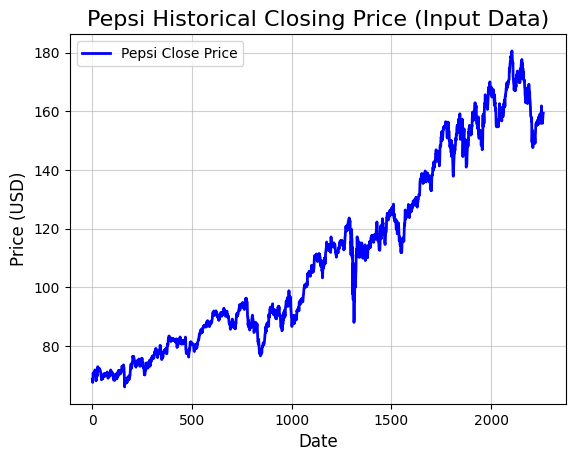

In [16]:
plt.Figure(figsize=(14,6))
# Plot the historical closing prices to see the raw input data trend
plt.plot(data["Close"],label="Pepsi Close Price",color="blue",linewidth=2)
plt.title(f"Pepsi Historical Closing Price (Input Data)",fontsize=16)
plt.xlabel("Date",fontsize=12)
plt.ylabel("Price (USD)",fontsize=12)
plt.legend(fontsize=10)
plt.grid(True,alpha=0.6)
plt.show()

Feature Scaling

In [17]:
# Initialize the StandardScaler (to normalize the data, which is crucial for linear models)
scaler = StandardScaler()
# Fit the scaler only on the training data and transform both sets
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
#  Scale the last known data point for new prediction
last_known_X_scaled = scaler.transform(last_known_X)

Model Training and Comparsion

In [18]:
#  Dictionary of models to compare
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(random_state=42), # L2 Regularization
    "Lasso Regression": Lasso(random_state=42), # L1 Regularization
    "Random Forest Regressor": RandomForestRegressor(random_state=42,n_jobs=1) # Non-linear model
}

results = {}
best_model_name = ""
best_rmse = float("inf")

In [19]:
print("-----  Training and Evaluating Models -----")

for name,model in models.items():
    # Train the model using the scaled training data
    model.fit(X_train_scaled,y_train)

    # Make predictions on the scaled test  set
    y_pred = model.predict(X_test)

    #  Calculate the performance metrics
    rmse = np.sqrt(mean_squared_error(y_test,y_pred)) # Root Mean Squared Error (Lower is better)
    r2 = r2_score(y_test,y_pred) # R-squared (Closer to 1.0 is better)

    # Store the results
    results[name] = {
        "RMSE":rmse,
        "R2": r2,
        "Model": model
    }

    # Update the best model tracker
    if rmse < best_rmse:
        best_rmse = rmse
        best_model_name = name

    print(f"{name} Results:")
    print(f"Root Mean Squared Error: {rmse:.4f}")
    print(f"R-squared (R2): {r2:.4f}")

-----  Training and Evaluating Models -----
Linear Regression Results:
Root Mean Squared Error: 3652.3188
R-squared (R2): -12876.5142
Ridge Regression Results:
Root Mean Squared Error: 3651.5266
R-squared (R2): -12870.9286
Lasso Regression Results:
Root Mean Squared Error: 3538.0718
R-squared (R2): -12083.4800
Random Forest Regressor Results:
Root Mean Squared Error: 76.8756
R-squared (R2): -4.7052


Hyperparameter Tuning: Random Forest Regressor

In [20]:
# Define the parameter grid to search over
param_grid = {
    "n_estimators":[50,100], #  Try 50 and 100 decison trees
    "max_depth":[10,20], # Limit the depth to prevent overfitting
    "min_samples_split":[5,10] # Minimum samples required to split a node
}

# Initialize the GridSearchCV (perform cross-validation across all parameter combinations)
grid_search = GridSearchCV(
    estimator=models["Random Forest Regressor"],
    param_grid=param_grid,
    cv=5,  # 5-fold cross-validation
    scoring="neg_mean_squared_error", # Objective:minimize MSE
    verbose=0,
    n_jobs=-1 # Use all available CPU cores for speed
)

# Fit the grid search to  the training  data
grid_search.fit(X_train_scaled,y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [10, 20], 'min_samples_split': [5, 10], 'n_estimators': [50, 100]}"
,scoring,'neg_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [21]:
#  Get the best estimator and its performance
best_rf_model = grid_search.best_estimator_
tuned_rf_pred = best_rf_model.predict(X_test_scaled)
tuned_rf_rmse = np.sqrt(mean_squared_error(y_test,tuned_rf_pred))
tuned_rf_r2 = r2_score(y_test,tuned_rf_pred)

print("----- Tuned Random Forest Regressor Results -----")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned RMSE: {tuned_rf_rmse:.4f}")
print(f"Tuned R2: {tuned_rf_r2:.4f}")

----- Tuned Random Forest Regressor Results -----
Best Parameters: {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 100}
Tuned RMSE: 0.1184
Tuned R2: 1.0000


In [22]:
# Update the results if the tuned model is better than the untuned version
if tuned_rf_rmse < results[best_model_name]['RMSE']:
    results['Tuned Random Forest'] = {'RMSE': tuned_rf_rmse, 'R2': tuned_rf_r2, 'Model': best_rf_model}
    best_model_name = 'Tuned Random Forest'
    print(f"\n-> Tuned Random Forest is now the best model!")

# Get the final best model
final_best_model = results[best_model_name]['Model']


-> Tuned Random Forest is now the best model!


Visualization After Training (Best Model Performance)

----- Visualizing Performance of the Best Model: Tuned Random Forest -----


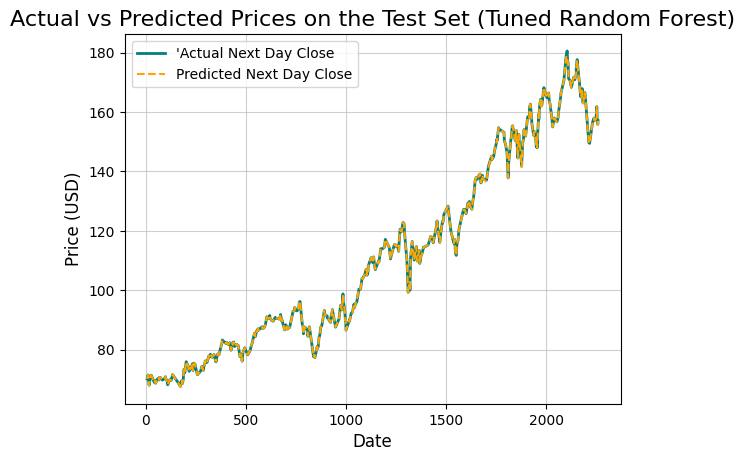

In [23]:
print(f"----- Visualizing Performance of the Best Model: {best_model_name} -----")

# Use the final best model to predict the entire test set
final_pred_test = final_best_model.predict(X_test_scaled)

# Create a DataFrame to compare actual vs predicted values easily
df_results = pd.DataFrame({
    "Actual":y_test,
    "Predicted":final_pred_test
})

# Sort by index (date) to plot them in the correct time series sequence
df_results.sort_index(inplace=True)

plt.Figure(figsize=(14,7))
# Plot the actual next day closing prices (the ground truth)
plt.plot(df_results.index,df_results["Actual"],label="'Actual Next Day Close",color="teal",linewidth=2)
# Plot the predicted next day closing prices (the model's output)
plt.plot(df_results.index,df_results["Predicted"],label="Predicted Next Day Close",color="orange",linestyle="--")

plt.title(f"Actual vs Predicted Prices on the Test Set ({best_model_name})",fontsize=16)
plt.xlabel("Date",fontsize=12)
plt.ylabel("Price (USD)",fontsize=12)
plt.legend(fontsize=10)
plt.grid(True,alpha=0.6)
plt.show()

Function for a New Prediction Input

In [24]:
def predict_next_day(model,last_X_scaled,ticker):
    """
    Predicts the next day's closing price using the trained model 
    based on the last available data point.
    """
    print(f"----- Prediction for the Day After Last Known Data Point -----")

    # The model predicts the price
    next_price_prediction = model.predict(last_X_scaled)[0]

    print(f"Using Model: {best_model_name}")
    print(f"Based on the last {LOOKBACK_DAYS} days of data, the predicted closing price for the next day of {TICKER} is: ${next_price_prediction:.2f}")


# Run the predicted function using the best model found
predict_next_day(final_best_model,last_known_X_scaled,TICKER)

----- Prediction for the Day After Last Known Data Point -----
Using Model: Tuned Random Forest
Based on the last 25 days of data, the predicted closing price for the next day of PEP is: $159.41


Final Summary of Performance

In [25]:
print("----- Final Model Comparison Summary -----")
#  Consolidate all model results, including the tuned model
all_models = {
    k:v for k,v in results.items()
}
# Create a DataFrame for a clean,comparative table
summary_df = pd.DataFrame({
    "Model":[name for name in all_models.keys()],
    "RMSE": [res["RMSE"] for res in all_models.values()],
    "R2 Score": [res["R2"] for res in all_models.values()]
}).sort_values(by="RMSE") # Sort by RMSE (Root Mean Squared Error) to find the best

# Display the final summary table
print(summary_df.to_markdown(index=False))

print(f"Conclusion: The best performing model based on RMSE is: {best_model_name}")

----- Final Model Comparison Summary -----
| Model                   |        RMSE |      R2 Score |
|:------------------------|------------:|--------------:|
| Tuned Random Forest     |    0.118433 |      0.999986 |
| Random Forest Regressor |   76.8756   |     -4.70521  |
| Lasso Regression        | 3538.07     | -12083.5      |
| Ridge Regression        | 3651.53     | -12870.9      |
| Linear Regression       | 3652.32     | -12876.5      |
Conclusion: The best performing model based on RMSE is: Tuned Random Forest
